# Customer Churn Prediction for a Telecommunications Company

v1.0

## Executive Summary

### Context

Customer churn represents a material financial risk. The objective of this analysis was to determine whether predictive targeting combined with retention incentives can generate positive economic value.

### Approach

We developed a churn prediction model to identify high-risk customers and quantified the financial implications of targeted retention campaigns. The analysis integrates:

- Predictive modeling to rank customers by churn probability
- Customer Lifetime Value (CLV) estimation
- Decile-based prioritization to optimize targeting  - 
- Probability threshold optimization to select customers maximizing expected ROI
- Scenario-based ROI simulations for alternative campaign strategies  

### Key Insights

1. **Churn risk is highly concentrated.**  
   The top decile of customers is 2.8x more likely to churn compared to random selection, enabling efficient targeting.

2. **Revenue exposure is significant.**  
   Estimated Revenue at Risk is approximately 1.96M USD if no intervention is implemented.

3. **Targeted retention is economically viable.**  
   - A campaign targeting only the top 10% of customers requires a 10.6% success rate to break even.  
   - Expanding the campaign to the top 30% (deciles 8–10) reduces the breakeven threshold to 6.66% and substantially increases upside potential.
   - A churn-focused campaign requires a 7.41% retention rate to break even and delivers a 2.08 ROI under the optimistic scenario.
   - The optimized campaign for ROI maximization has a cost of 53,560 USD and achieves a 2.23 ROI under the optimistic scenario.

4. **Risk-return profile favors broader targeting.**  
   Under neutral and optimistic scenarios, the 30% targeting strategy generates materially higher ROI while maintaining manageable downside risk, while both the churn-focused and optimized strategies further improve upside efficiency.

### Recommendation

Prioritize the optimized retention campaign as the primary strategy for maximizing ROI.

While the top 30% targeting strategy (deciles 8–10) provides the lowest breakeven threshold (6.66%) and strong scalability, the optimized campaign delivers the highest return (ROI 2.23) with disciplined cost allocation.

The churn-focused campaign also demonstrates strong upside potential (ROI 2.08) and can be deployed as a complementary strategy.

This approach offers:
- Strong ROI maximization
- Controlled downside risk
- Capital-efficient targeting

The analysis demonstrates that integrating predictive analytics with financial modeling enables disciplined, value-driven retention decisions rather than intuition-based marketing spend.

## Introduction


In telecom companies, customer retention is more cost-effective than customer acquisition. Therefore, predicting churn and understanding its causes is critical for a company's growth.

In this project, we analyzed the key drivers of customer churn, identified the most predictive variables, implemented a machine learning algorithm to estimate the probability of churn for customers, identified target groups for retention campaigns using lift analysis, and evaluated the business implications across different scenarios.

## Library and data load

In [1]:
import pandas as pd
import numpy as np
from scipy import stats


import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_auc_score, roc_curve, f1_score, precision_score, recall_score, precision_recall_curve
from sklearn.model_selection import KFold,StratifiedKFold, cross_validate, train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [2]:
# set plotting parameters
font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size' : 10}
axes = { 'titlesize' : 15,
         'labelsize' : 13}
figure = {'figsize':(10,4),
          'autolayout':True,
         'titlesize' : 25,
         'labelsize' : 13}
my_palette = {0: 'steelblue', 1: 'darkorange', 'No': 'steelblue', 'Yes': 'darkorange'}
plt.rc('font', **font)
plt.rc('axes', **axes)
plt.rc('figure', **figure)

In [3]:
# load dataset
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [4]:
# Visual options
from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage, .jp-OutputArea-output img {
    display: block;
    margin-left: auto;
    margin-right: auto;
}
</style>
""")

## Data Overview and Cleaning

In [5]:
pd.set_option('display.max_columns', None)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Data Types

In [6]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


'TotalCharges' must be converted to a numerical variable.

In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

For consistency in the analysis, 'SeniorCitizen' must be treated as a categorical variable ('Yes', 'No') instead of a numerical one (1, 0).

In [8]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({1: 'Yes', 0: 'No'})

### Missing Values

We check for null or NaN values:

In [9]:
print(df.isnull().sum().sort_values(ascending=False))

TotalCharges        11
customerID           0
DeviceProtection     0
MonthlyCharges       0
PaymentMethod        0
PaperlessBilling     0
Contract             0
StreamingMovies      0
StreamingTV          0
TechSupport          0
OnlineBackup         0
gender               0
OnlineSecurity       0
InternetService      0
MultipleLines        0
PhoneService         0
tenure               0
Dependents           0
Partner              0
SeniorCitizen        0
Churn                0
dtype: int64


There are some null values in 'TotalCharges'. Let's examine them.

In [10]:
df[df['TotalCharges'].isna()].index

Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')

In [11]:
df[df['TotalCharges'].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,No,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,No,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


All rows with NaN values in 'TotalCharges' have a tenure of 0.

In [12]:
print(df[ df['tenure']==0 ].index)
print(df[ df['tenure']==0 ])

Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')
      customerID  gender SeniorCitizen Partner Dependents  tenure  \
488   4472-LVYGI  Female            No     Yes        Yes       0   
753   3115-CZMZD    Male            No      No        Yes       0   
936   5709-LVOEQ  Female            No     Yes        Yes       0   
1082  4367-NUYAO    Male            No     Yes        Yes       0   
1340  1371-DWPAZ  Female            No     Yes        Yes       0   
3331  7644-OMVMY    Male            No     Yes        Yes       0   
3826  3213-VVOLG    Male            No     Yes        Yes       0   
4380  2520-SGTTA  Female            No     Yes        Yes       0   
5218  2923-ARZLG    Male            No     Yes        Yes       0   
6670  4075-WKNIU  Female            No     Yes        Yes       0   
6754  2775-SEFEE    Male            No      No        Yes       0   

     PhoneService     MultipleLines InternetService       OnlineSecurity  \
488      

The rows with missing values in 'TotalCharges' are the same ones that have a tenure of 0, which is a consequence of not having paid yet.
Since these clients have not had sufficient time to churn, they were excluded from the analysis.

In [13]:
df.drop(df[ df['tenure'] == 0 ].index, inplace=True)

In [14]:
df.shape

(7032, 21)

## EDA

In [15]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   object 
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


Highly relevant information:

In [16]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

The distribution is not balanced, but it's not highly imbalanced.

In [17]:
for col in df.columns:
    if df[col].dtype != 'int64' and df[col].dtype != 'float64':
        print(f'{col} : {df[col].unique()}')

customerID : ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender : ['Female' 'Male']
SeniorCitizen : ['No' 'Yes']
Partner : ['Yes' 'No']
Dependents : ['No' 'Yes']
PhoneService : ['No' 'Yes']
MultipleLines : ['No phone service' 'No' 'Yes']
InternetService : ['DSL' 'Fiber optic' 'No']
OnlineSecurity : ['No' 'Yes' 'No internet service']
OnlineBackup : ['Yes' 'No' 'No internet service']
DeviceProtection : ['No' 'Yes' 'No internet service']
TechSupport : ['No' 'Yes' 'No internet service']
StreamingTV : ['No' 'Yes' 'No internet service']
StreamingMovies : ['No' 'Yes' 'No internet service']
Contract : ['Month-to-month' 'One year' 'Two year']
PaperlessBilling : ['Yes' 'No']
PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn : ['No' 'Yes']


Plot of categorical variables related to the client and their family

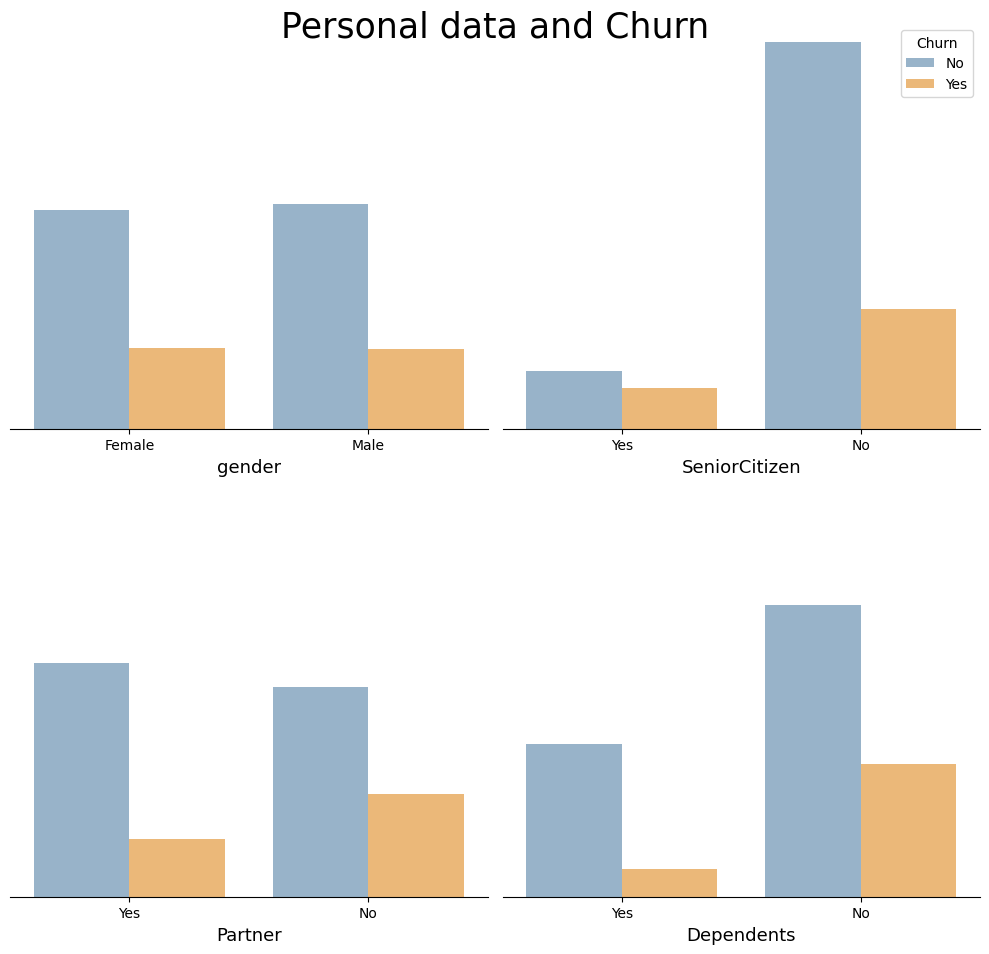

In [18]:
# Set the subplots
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2, 2,  sharey=True, figsize=(10,10))

fig.suptitle('Personal data and Churn',  y=0.95)

sns.despine(top=True, right=True,left=True) # Quit the axes
ax2.set_yticks([]) #quit the ticks
ax4.set_yticks([])


sns.countplot(data = df, 
              x = 'gender', 
              hue = 'Churn', 
              ax = ax1,
              alpha = 0.6, 
              palette=my_palette,
              legend = False)
sns.countplot(data=df, 
              x = 'SeniorCitizen', 
              hue = 'Churn', 
              ax = ax2,
              alpha = 0.6, 
              palette=my_palette,
              order = ['Yes', 'No'], 
              legend = False)
ax2.legend(title='Churn', labels=['No', 'Yes'])
sns.countplot(data = df, 
              x = 'Partner', 
              hue = 'Churn',
              ax = ax3, 
              alpha = 0.6,
              palette=my_palette,
              order = ['Yes', 'No'], 
              legend = False)
sns.countplot(data = df, 
              x = 'Dependents', 
              hue = 'Churn',
              ax = ax4,
              alpha = 0.6, 
              palette=my_palette,
              order = ['Yes', 'No'], 
              legend = False);

In the personal/family characteristics, the distribution of churn is almost equal by gender, slightly different by partners or not, and strongly different for dependents (being more prone to churn the clients without dependents) and notably higher among Senior Citizens, with a significantly greater propensity to churn compared to younger customers.

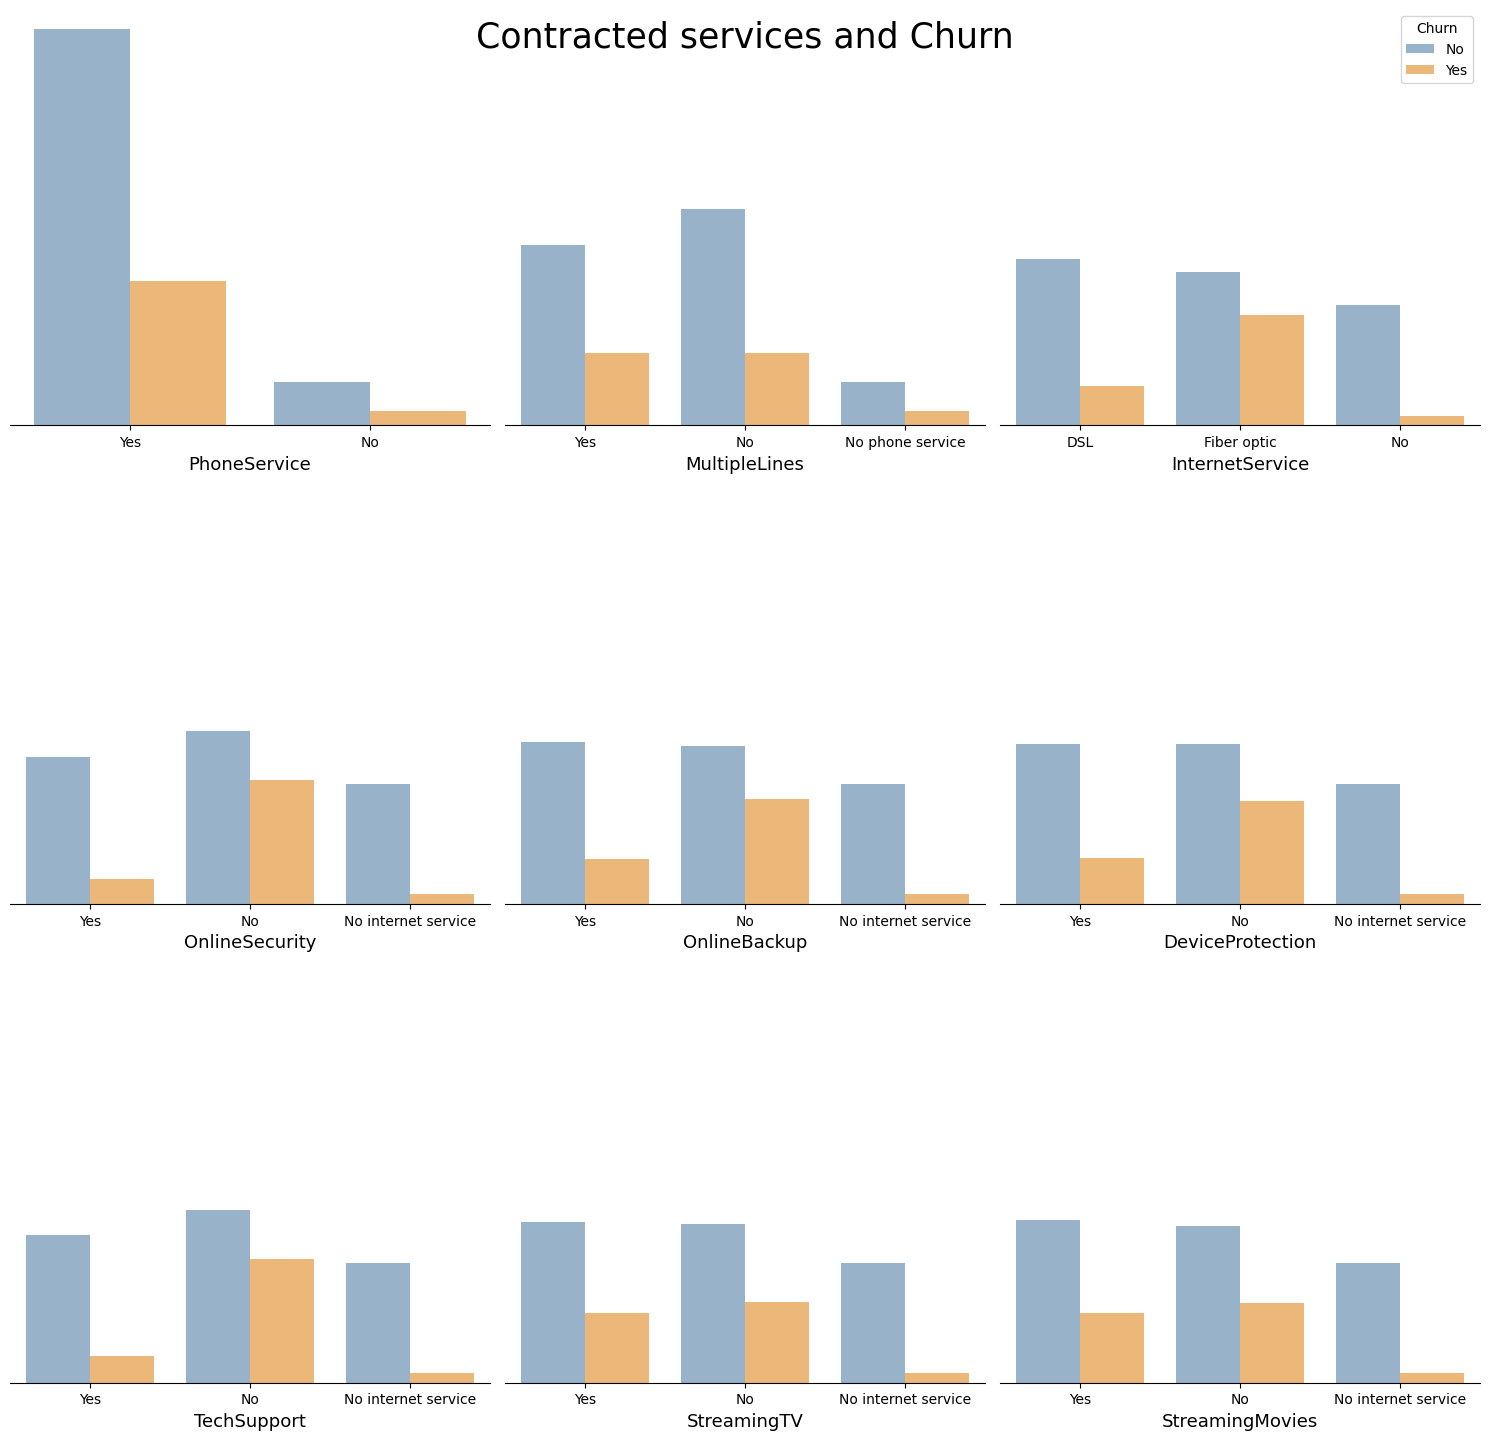

In [19]:
# create a 3x3 grid of subplots
fig, ((ax1,ax2,ax3), (ax4,ax5,ax6), (ax7,ax8,ax9)) = plt.subplots(3, 3,  sharey=True, figsize=(15,15))

fig.suptitle('Contracted services and Churn',  y=0.95)

sns.despine(top=True, right=True,left=True) # Quit the axes
ax2.set_yticks([]) #quit the ticks

sns.countplot(data=df, 
              x='PhoneService', 
              hue='Churn',
              ax =ax1, 
              alpha=0.6,
              palette=my_palette,
              order=['Yes', 'No'], 
              legend=False)
sns.countplot(data=df, 
              x='MultipleLines', 
              hue='Churn',
              ax =ax2, 
              alpha=0.6,
              palette=my_palette,
              order=['Yes', 'No', 'No phone service'], 
              legend=False)
sns.countplot(data=df, 
              x='InternetService', 
              hue='Churn',
              ax =ax3,
              alpha=0.6,
              palette=my_palette,
              legend=False)
ax3.legend(title='Churn', labels=['No', 'Yes'])
sns.countplot(data=df, 
              x='OnlineSecurity', 
              hue='Churn',
              ax =ax4, 
              alpha=0.6,
              palette=my_palette,
              order=['Yes', 'No','No internet service'], 
              legend=False)
sns.countplot(data=df, 
              x='OnlineBackup', 
              hue='Churn',
              ax =ax5, 
              alpha=0.6,
              palette=my_palette,
              order=['Yes', 'No','No internet service'], 
              legend=False)
sns.countplot(data=df,
              x='DeviceProtection', 
              hue='Churn',
              ax =ax6, 
              alpha=0.6,
              palette=my_palette,
              order=['Yes', 'No','No internet service'], 
              legend=False)
sns.countplot(data=df, 
              x='TechSupport', 
              hue='Churn',
              ax =ax7, 
              alpha=0.6,
              palette=my_palette,
              order=['Yes', 'No','No internet service'], 
              legend=False)
sns.countplot(data=df, 
              x='StreamingTV', 
              hue='Churn',
              ax =ax8, 
              alpha=0.6,
              palette=my_palette,
              order=['Yes', 'No','No internet service'], 
              legend=False)
sns.countplot(data=df, 
              x='StreamingMovies', 
              hue='Churn',
              ax =ax9,
              alpha=0.6, 
              palette=my_palette,
              order=['Yes', 'No','No internet service'], 
              legend=False);


The phone client characteristics do not seem to distinguish the prone to churn. On the other hand, the internet clients with fewer services seems to be more prone to churn.

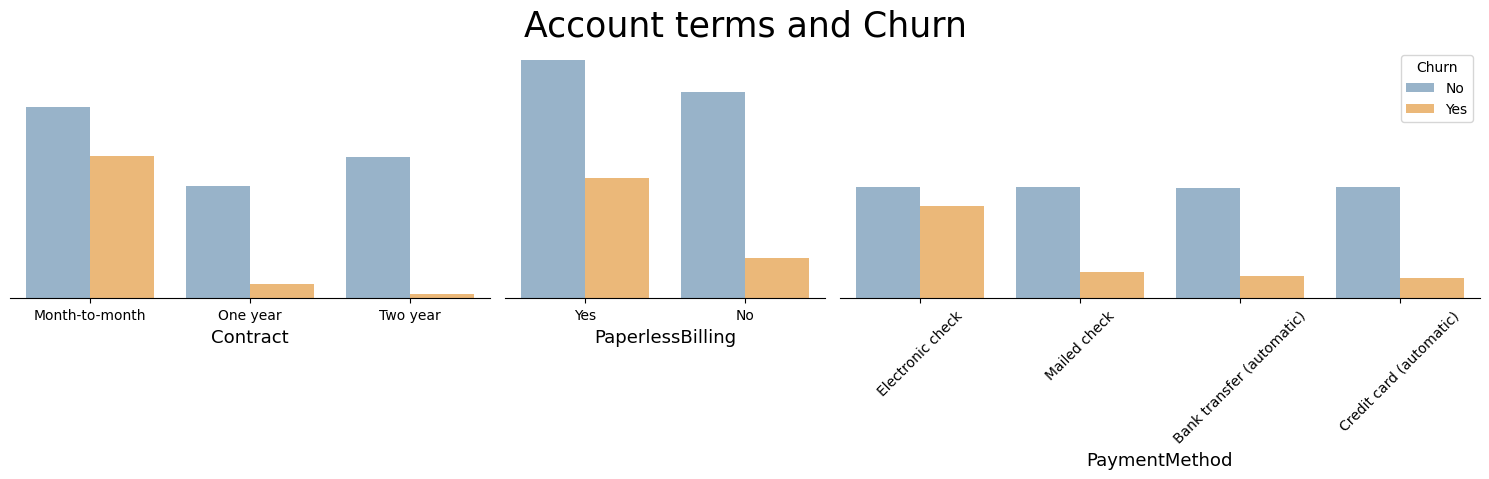

In [20]:
fig, (ax1,ax2,ax3) = plt.subplots(1, 3,  sharey=True, figsize=(15,5), gridspec_kw={'width_ratios': [3, 2, 4]})

fig.suptitle('Account terms and Churn',  y=0.95)

sns.despine(top=True, right=True,left=True) # quit the axes
ax2.set_yticks([]) #quit the ticks

sns.countplot(data=df, 
              x='Contract', 
              hue='Churn',
              ax =ax1,
              alpha=0.6,
              palette=my_palette,
              legend=False)
sns.countplot(data=df, 
              x='PaperlessBilling', 
              hue='Churn',
              ax =ax2,
              alpha=0.6, 
              palette=my_palette,
              legend=False)
sns.countplot(data=df, 
              x='PaymentMethod', 
              hue='Churn',
              ax =ax3,
              alpha=0.6,
              palette=my_palette)
ax3.legend(title='Churn', labels=['No', 'Yes'])
ax3.tick_params(axis='x', rotation=45);


We consider now the original numerical variables: tenure, MonthlyCharges and TotalCharges.

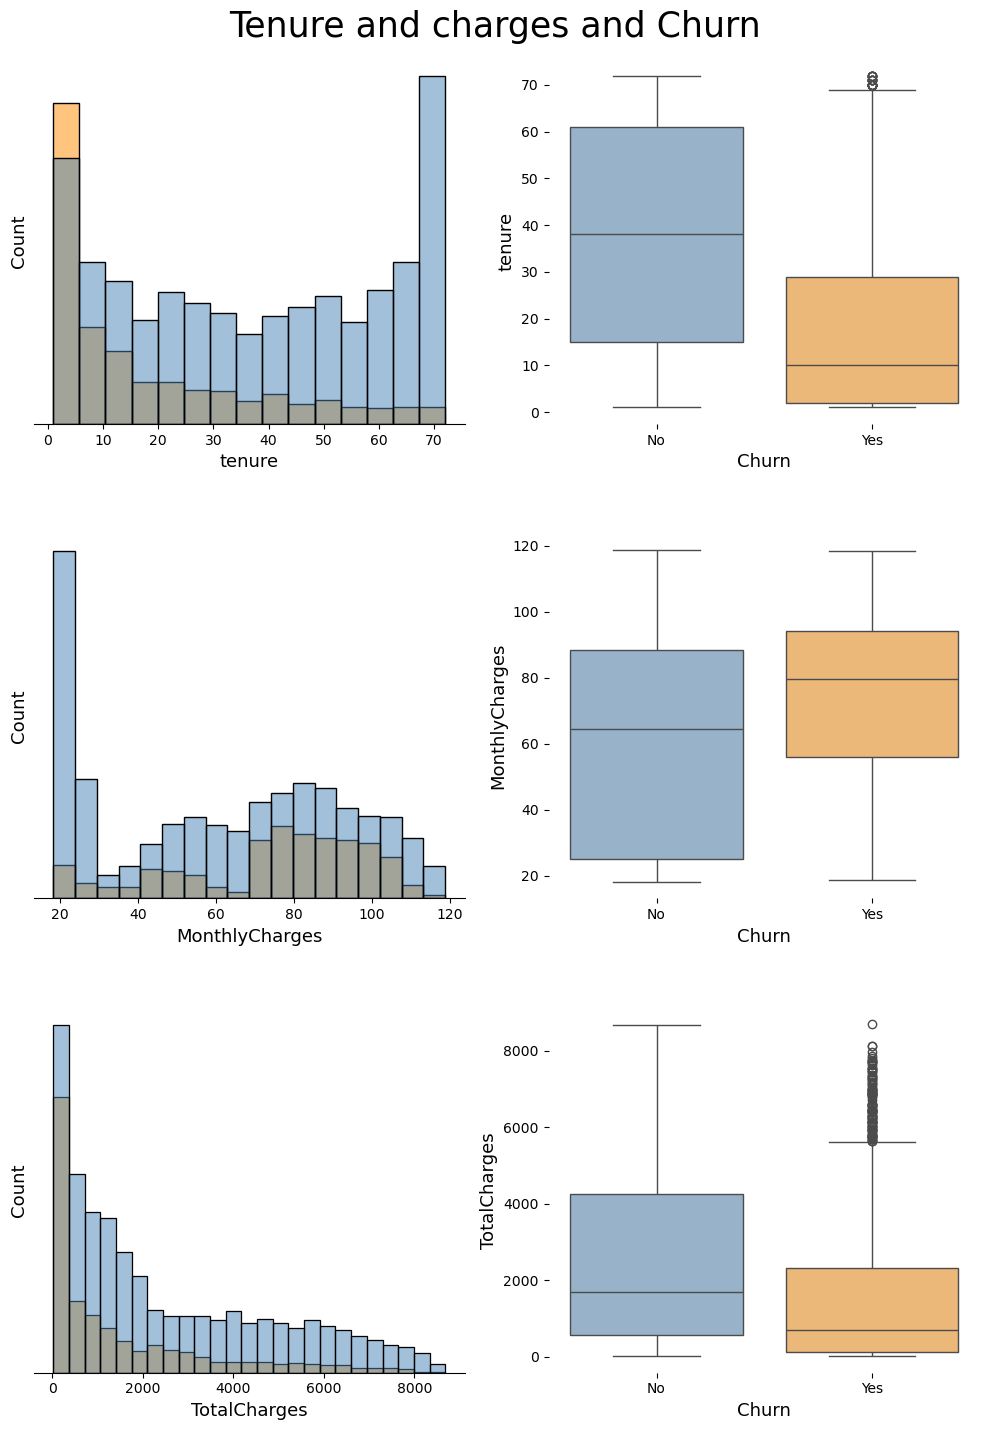

In [21]:
fig, ((ax1,ax2),(ax3,ax4),(ax5,ax6)) = plt.subplots(3, 2,   figsize=(10,15))
sns.despine(top=True, right=True, left=True) # Quit the axes

fig.suptitle('Tenure and charges and Churn',  y=0.95)

sns.histplot(data=df, 
             x='tenure', 
             hue='Churn',  
             kde=False, 
             ax=ax1, 
             palette=my_palette,        
             legend=False)
ax1.set_yticks([]) #quit the ticks

sns.boxplot(data=df, 
            x='Churn', 
            y='tenure',
            hue='Churn',  
            ax=ax2, 
            palette=my_palette,        
            legend=False)
ax2.set_xticks([0, 1]) 
ax2.set_xticklabels(['No', 'Yes'])
ax2.spines['bottom'].set_visible(False)
for patch in ax2.patches: # adjust the color to obtain the same in histplot and subplot
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.6))


sns.histplot(data=df, 
             x='MonthlyCharges', 
             hue='Churn', 
             kde=False, 
             ax=ax3, 
             palette=my_palette,        
             legend=False)
ax3.set_yticks([]) #quit the ticks

sns.boxplot(data=df, 
            x='Churn', 
            y='MonthlyCharges', 
            hue='Churn',  
            ax=ax4, 
            palette=my_palette,        
            legend=False)
ax4.set_xticks([0, 1]) # Primero definimos las posiciones
ax4.set_xticklabels(['No', 'Yes'])
ax4.spines['bottom'].set_visible(False)
for patch in ax4.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.6))
    

sns.histplot(data=df, 
             x='TotalCharges', 
             hue='Churn', 
             kde=False, 
             palette=my_palette,        
             ax=ax5, 
             legend=False)
ax5.set_yticks([]) #quit the ticks

sns.boxplot(data=df, 
            x='Churn', 
            y='TotalCharges', 
            hue='Churn',  
            ax=ax6, 
            palette=my_palette,        
            legend=False);
ax6.set_xticks([0, 1]) # Primero definimos las posiciones
ax6.set_xticklabels(['No', 'Yes'])
ax6.spines['bottom'].set_visible(False)
for patch in ax6.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.6))

plt.tight_layout(rect=[0, 0, 1, 0.96])
fig.subplots_adjust(hspace=0.3)
plt.show()

From the 'tenure' plots it's clear that the new clients are more prone to churn with a high proportion in the first year and even more in the first month.
Despite a group of very low 'MonthlyCharges' with no churn, the 'MonthlyCharges' seem to be related to the churn.
The TotalCharges shows a more significant relationship: low 'TotalCharges' have a high rate of churn, and, according to 'TotalCharges' increases, the churn rate decays.
It's observable, also, that there is a group of churn for high values of 'tenure' and 'TotalCharges'.

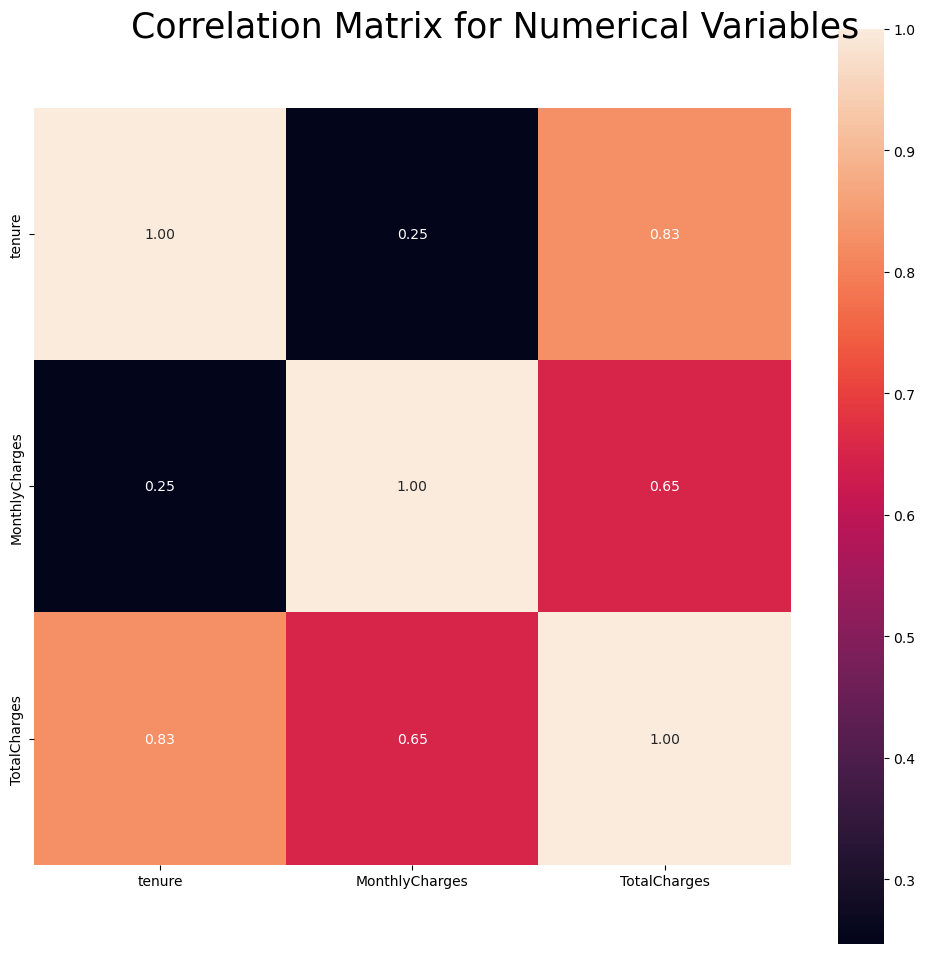

In [22]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numerical_cols].corr()

fig = plt.figure(figsize=(10, 10))
fig.suptitle('Correlation Matrix for Numerical Variables',  y=0.95)
sns.heatmap(correlation_matrix, annot=True, fmt=".2f",  square=True)

plt.show()

The correlation matrix shows the obvious relationships among charges, VAS and tenure.

### Feature Engineering

In order to explore the relevance of the amount of internet services (Value-Added Services), we add a feature 'VAS Count' which is the amount of these services contracted: OnlineSecurity, OnlineBackup, DeviceProtection and TechSupport. Also, consider the feature 'VAS Stream' which is the sum of streaming services. Finally, 'VAS Count tot'='VAS Count'+'VAS Stream' plus StreamingTV and StreamingMovies.

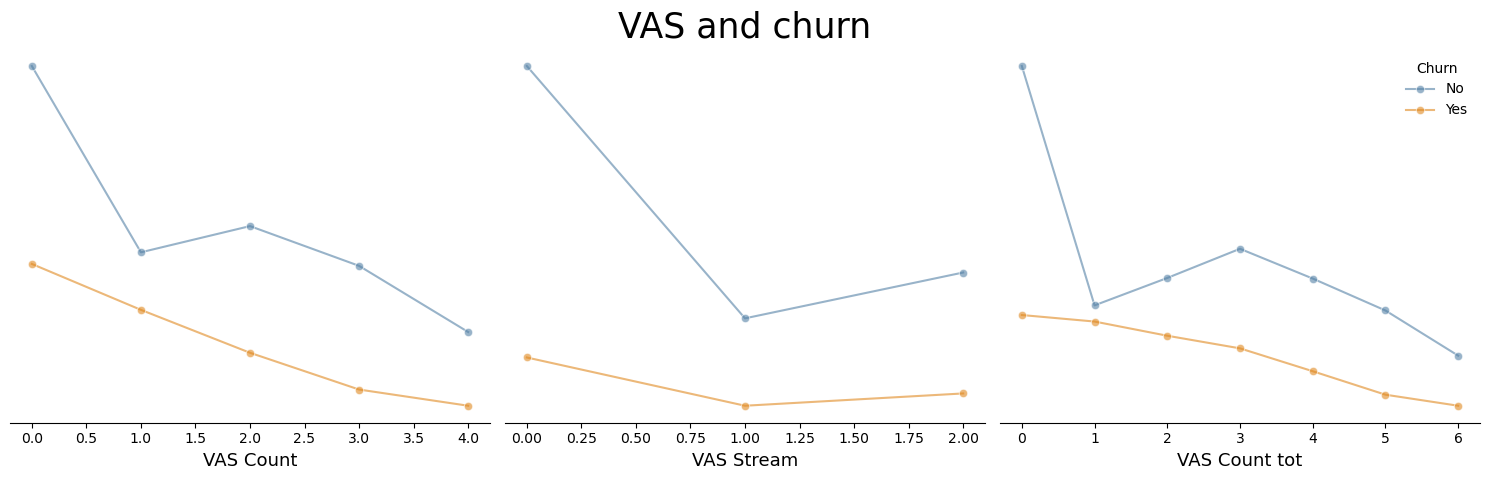

In [23]:
# Create the three new features
df['VAS Count'] = (df[[ 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']] == 'Yes').sum(axis=1)
df['VAS Stream'] = (df[['StreamingTV', 'StreamingMovies']] == 'Yes').sum(axis=1)
df['VAS Count tot'] = (df[[ 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport','StreamingTV', 'StreamingMovies']] == 'Yes').sum(axis=1)

# Create the subplots gride
fig, (ax1,ax2,ax3) = plt.subplots(1, 3,  sharey=False, figsize=(15,5))
sns.despine(top=True, right=True, left=True) # Quit the axes
my_palette = ["#5481A6", "#E08920"]
fig.suptitle('VAS and churn',  y=0.95)

ax1.set_yticks([])
df_counts1 = df.groupby(['VAS Count', 'Churn']).size().reset_index(name='counts')
sns.lineplot(data=df_counts1, 
             x='VAS Count', 
             y='counts', 
             hue=df_counts1['Churn'],             
             marker='o', 
             ax=ax1, 
             alpha=0.6, 
             palette=my_palette,        
             legend=False)

ax2.set_yticks([]) #quit the ticks
df_counts2 = df.groupby(['VAS Stream', 'Churn']).size().reset_index(name='counts')
sns.lineplot(data=df_counts2, 
             x='VAS Stream', 
             y='counts', 
             hue=df_counts2['Churn'], 
             marker='o', 
             ax=ax2, 
             alpha=0.6, 
             palette=my_palette,        
             legend=False)

ax3.set_yticks([])
df_counts3 = df.groupby(['VAS Count tot', 'Churn']).size().reset_index(name='counts')
sns.lineplot(data=df_counts3, 
             x='VAS Count tot', 
             y='counts', 
             hue=df_counts3['Churn'], 
             marker='o', 
             ax=ax3, 
             alpha=0.6,
             palette=my_palette)
ax3.legend(title='Churn', frameon=False);


The trend for no churn with high VAS is clear, and the low churn for 0 VAS could be caused by the phone clients without internet service.

We introduce a new feature: the quotient 'MonthlyCharges' over 'TotalCharges'.
Remark: previously we already defined 'VAS Count', 'VAS Stream' and 'VAS count tot'.

In [24]:
df['quotient'] = df['TotalCharges']/df['MonthlyCharges']

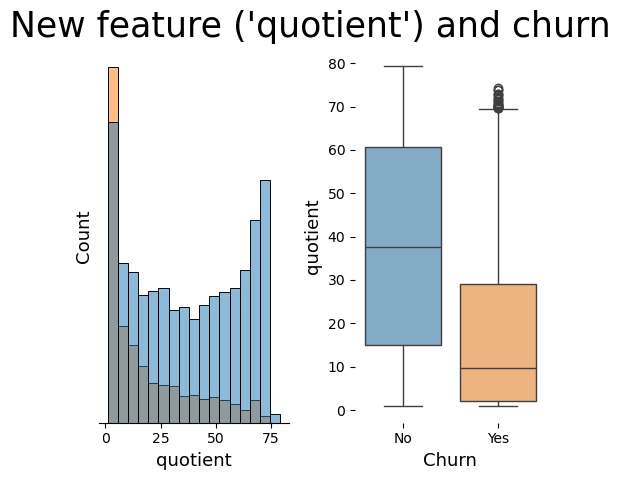

In [25]:
fig, ((ax1,ax2)) = plt.subplots(1, 2,   figsize=(5,5))
sns.despine(top=True, right=True, left=True) # Quit the axes

fig.suptitle("New feature ('quotient') and churn",  y=0.95)

sns.histplot(data=df, 
             x='quotient', 
             hue='Churn',  
             kde=False, 
             ax=ax1, 
             legend=False)
ax1.set_yticks([]) #quit the ticks

sns.boxplot(data=df, 
            x='Churn', 
            y='quotient',
            hue='Churn',  
            ax=ax2, 
            legend=False)
ax2.spines['bottom'].set_visible(False)
for patch in ax2.patches: # adjust the color to obtain the same in histplot and subplot
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.6))

We can see that this new feature splits churn better than the original ones.

### EDA Summary

Number of clients: 7,032

Missing values: 0 (11 records were discarded as they are too new to have all features populated).

Churned clients: 1,869

Categorical features: 16

Numerical features: 3

_**New Features:**_

VAS count, VAS stream, VAS count total: Numerical variables representing the sum of affirmative categorical "Value Added Services".

Quotient: The ratio between 'TotalCharges' and 'MonthlyCharges'.

**Main Observations:**

Gender: Does not significantly discern or predict churn.

Demographics: Clients with partners, dependents, or who are senior citizens show lower churn rates.

Phone Services: Clients with phone services and multiple lines show lower churn.

Internet Service: Fiber optic users have a higher churn rate.

Contracts: Clients with month-to-month contracts have higher churn.

Payment Method: Clients using electronic payment methods show higher churn.

Tenure: New clients (tenure less than a year) have higher churn; increased tenure is strongly correlated with lower churn.

Charges: Clients with very low monthly charges show very low churn, though this trend is not as evident in total charges.

VAS: Clients with more Value Added Services show a lower churn rate proportional to the number of services contracted.


## Machine Learning

In [26]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64

We have the 'Churn' values slightly unbalanced.

We encode the target variable ('Churn') as 0 and 1; and, separe numerica and categorical variables.

In [27]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

# Define target
target = 'Churn'

# Define categorical columns
categorical_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'SeniorCitizen',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

# Define numerical columns
numeric_cols = [col for col in df.columns if col not in categorical_cols + [target]+['customerID']]

# separe features and target
X = df[categorical_cols + numeric_cols]
y = df[target]


We set four common models for classification: Logistic Regression, Support Vector Classifier, Random Forest and XGBoost. We establish a preprocessor with StandardScaler for numerical variables, given that we have variables of quite different magnitude. We use OneHotEncoder for categorical variables.

In [28]:
# define models with usual parameters
models = {
    "LogReg": LogisticRegression(max_iter=1000, random_state=42),
    "SVC": SVC(probability=True),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=43),
    "XGBoost": XGBClassifier(
        eval_metric = 'logloss',
        random_state = 43,
        n_estimators = 300,
        learning_rate = 0.1,
        max_depth = 6
    )
}
# preprocesor pipeline
numeric_transformer = Pipeline([('scaler', StandardScaler())])
# encode for categorical variables
categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')
# combination of preprocessors
preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_cols),
                                               ('cat', categorical_transformer, categorical_cols)])


For avoiding leakage, we split the test and train data in a stratified way: 80% train and 20% test.

In [29]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=43) # This makes a crossvalidation stratified, considering the unbalanced chrun

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=43, 
    stratify=y # Splitting considering the unbalanced chrun
)

We define five metrics to evaluate the models using Cross validation with stratified k fold over the train set. 

In [30]:
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

results_table = []

for name, model in models.items():
    print(f"Evaluando {name}...")
    
    # create pipeline
    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('model', model)
    ])
    
    # evaluate metrics with cross validation
    scores = cross_validate(pipe, 
                            X_train, 
                            y_train, 
                            cv=skf, 
                            scoring=metrics)
    
    results_table.append({
        'Model': name,
        'Acc': scores['test_accuracy'].mean(),
        'Pre': scores['test_precision'].mean(),
        'Rec': scores['test_recall'].mean(),
        'F1': scores['test_f1'].mean(),
        'AUC': scores['test_roc_auc'].mean()
    })

# dataframe for better visualization
df_results = pd.DataFrame(results_table)
print(df_results)

Evaluando LogReg...
Evaluando SVC...
Evaluando RandomForest...
Evaluando XGBoost...
          Model       Acc       Pre       Rec        F1       AUC
0        LogReg  0.803556  0.656584  0.547826  0.596740  0.841851
1           SVC  0.800000  0.674821  0.478261  0.559314  0.787035
2  RandomForest  0.792178  0.644088  0.486288  0.553368  0.822511
3       XGBoost  0.783111  0.609183  0.513712  0.557064  0.821687


The AUC is the metric we select for the model choice. This metric works well even in unbalanced sets. Based on the AUC score, the best choice is Logistic regression. Now we tune the parameters

In [31]:
# Set the pipeline with the selected model
pipe_final = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=10000, class_weight='balanced', random_state=42))
])

# set the grid of parameter values
param_distributions = {
    'model__C': np.logspace(-4, 4, 20),
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear']
}

# Set the search by better roc_auc
search = RandomizedSearchCV(pipe_final, 
                            param_distributions = param_distributions, 
                            n_iter = 25, 
                            cv = skf, # the crosvalidation stratified
                            scoring = 'roc_auc',
                            random_state=43,
                            n_jobs=-1)


search.fit(X_train, y_train)

print(f"Best AUC after tuning: {search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")

Best AUC after tuning: 0.8417
Best params: {'model__solver': 'liblinear', 'model__penalty': 'l1', 'model__C': np.float64(11.288378916846883)}


### Model Results and Evaluation

Now we train the model with the best parameters and apply the model on the test set

In [32]:
# Make predictions on test
y_proba = search.best_estimator_.predict_proba(X_test)[:, 1]
y_pred = search.best_estimator_.predict(X_test)

print("Classification report on test:")
print(classification_report(y_test, y_pred))
print(f"Final AUC on Test: {roc_auc_score(y_test, y_proba):.4f}")

Classification report on test:
              precision    recall  f1-score   support

           0       0.92      0.70      0.79      1033
           1       0.50      0.82      0.62       374

    accuracy                           0.73      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.81      0.73      0.75      1407

Final AUC on Test: 0.8517


We plot the ROC curve

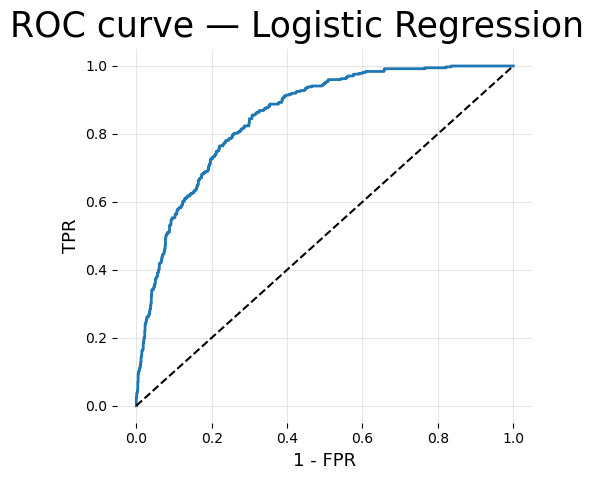

In [33]:
# 
fpr_pro, tpr_pro, _ = roc_curve(y_test, y_proba)
auc_pro = roc_auc_score(y_test, y_proba)

fig = plt.figure(figsize=(5,5))
plt.plot(fpr_pro, tpr_pro, label=f"Logistic Regression (AUC={auc_pro:.3f})", linewidth=2)
plt.plot([0,1], [0,1], 'k--', label="Random")

fig.suptitle("ROC curve — Logistic Regression",  y=0.95)
plt.xlabel("1 - FPR")
plt.ylabel("TPR")
sns.despine(top=True, right=True, left=True, bottom=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

We construct a decile lift chart.

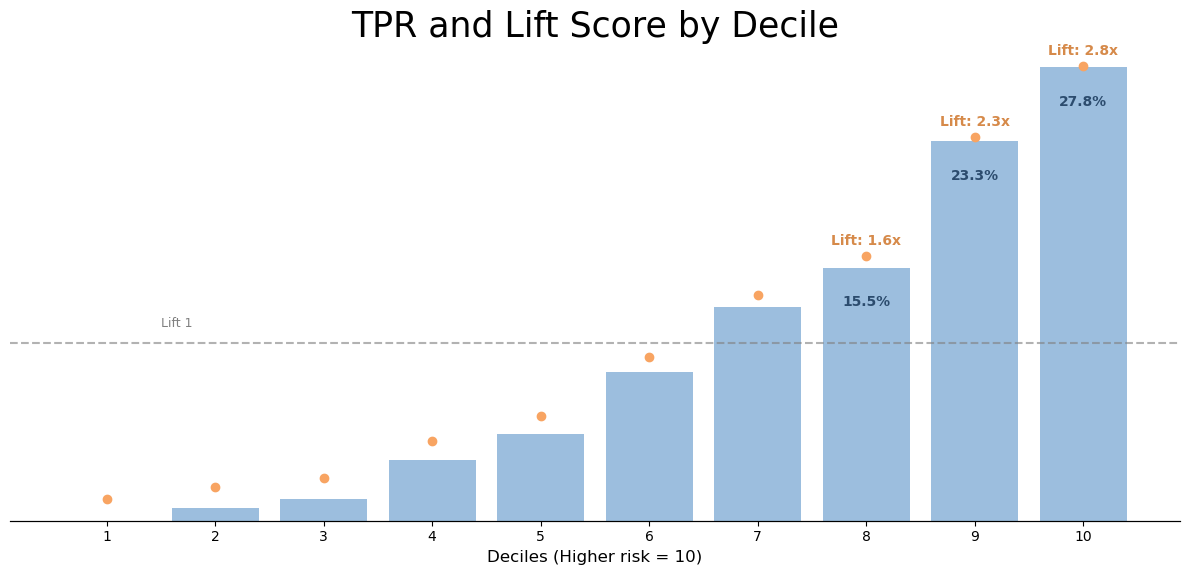

In [34]:
# Prepare the data
df_results = pd.DataFrame({
                'real': y_test, 
                'prob': y_proba
                })

df_results = df_results.sort_values(by='prob', ascending=True)

df_results['decil'] = pd.qcut(
                            df_results['prob'].rank(method='first'), 
                            10, 
                            labels=range(1, 11) # Las probabilidades más altas obtendrán el 10
                            )

# base churn rate
base_rate = df_results['real'].mean()

total_posit = sum(y_test)

# grouping by decil TPR and Lift
stats_decil = df_results.groupby('decil', observed=False)['real'].agg(['sum', 'count'])
stats_decil['tpr'] = stats_decil['sum'] / total_posit
stats_decil['precision_decil'] = stats_decil['sum'] / stats_decil['count']
stats_decil['lift'] = stats_decil['precision_decil'] / base_rate

fig, ax1 = plt.subplots(figsize=(12, 6))
sns.despine(top=True, right=True, left=True)

# Values for last 3 deciles
n = len(stats_decil)
# for TPR
tpr_labels = [""] * (n - 3) + [f'{val:.1%}' for val in stats_decil['tpr'].values[-3:]]
# for lift
lift_labels = [""] * (n - 3) + [f'Lift: {val:.1f}x' for val in stats_decil['lift'].values[-3:]]


barras = ax1.bar(stats_decil.index.astype(str),  
                 stats_decil['tpr'], 
                 color='#72a3d0', 
                 alpha=0.7, )
# add the TPR values
ax1.bar_label(barras, 
              labels = tpr_labels, 
              padding = -30, 
              fontsize = 10, 
              fontweight = 'bold', 
              color = '#2c4c6e')

ax1.set_xlabel('Deciles (Higher risk = 10)', fontsize=12)

ax1.set_yticks([]) 

ax2 = ax1.twinx() # second axis

ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_yticks([]) 

# lift markers
linea = ax2.plot(stats_decil.index.astype(str), 
                 stats_decil['lift'], 
                 color='#f8a462', 
                 marker='o', 
                 linestyle='None', 
                 label='Lift Score')


for i, valor_lift in enumerate(stats_decil['lift']):
    ax2.text(x = i, 
             y = valor_lift + 0.05,  
             s = lift_labels[i], 
             color = '#d68a4a', 
             fontweight = 'bold', 
             fontsize = 10,
             ha = 'center', 
             va = 'bottom')

# Lift=1
ax2.axhline(1, 
            color = 'gray', 
            linestyle = '--', 
            alpha = 0.6)
ax2.annotate('Lift 1', 
             xy = (0.5, 1.1), 
             color = 'gray', 
             fontsize = 9)

fig.suptitle('TPR and Lift Score by Decile',  y=0.95)
fig.tight_layout()
plt.show()

By targeting the top decile, we are 2.8 times more likely to find a potential churn compared to a random selection. With the three highest deciles, we capture 66.6% of churned clients. In this case, we have a very attractive target segment for identifying potential churners.

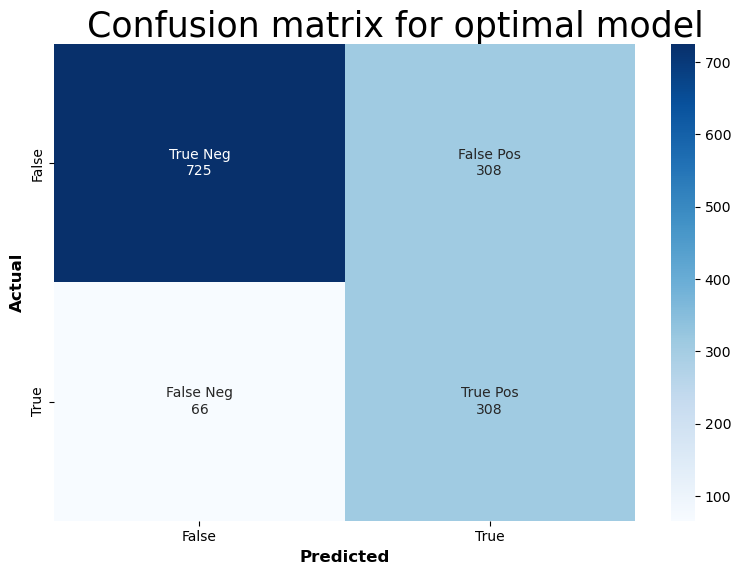

In [35]:
cm = confusion_matrix(y_test, y_pred)

# Tags for blocks
group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]

# preparing labels
labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names, group_counts)]
labels = np.asarray(labels).reshape(2,2)


fig = plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', 
            xticklabels=['False', 'True'], 
            yticklabels=['False', 'True'])

plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.ylabel('Actual', fontsize=12, fontweight='bold')
fig.suptitle('Confusion matrix for optimal model',  y=0.95)
plt.show()

We have many "FP" cases but very few "FN" cases. A "FP" could drive us to make an effort to retain a client who does not intend to leave, an inefficient allocation of resources. An "FN" could drive us to not care about one churn. For this reason, the kind of error most frequent in our model is the least important for our purpose.

We can use the coefficients of the logistic regression to analyze the impact of each variable. For a better understanding, we use the odds ratios.
Variables that express a propensity to churn have odds ratios greater than 1. An odds ratio of 1.25 increases churn risk by 25%. An odds ratio of 0.8 diminishes the churn risk 20%.

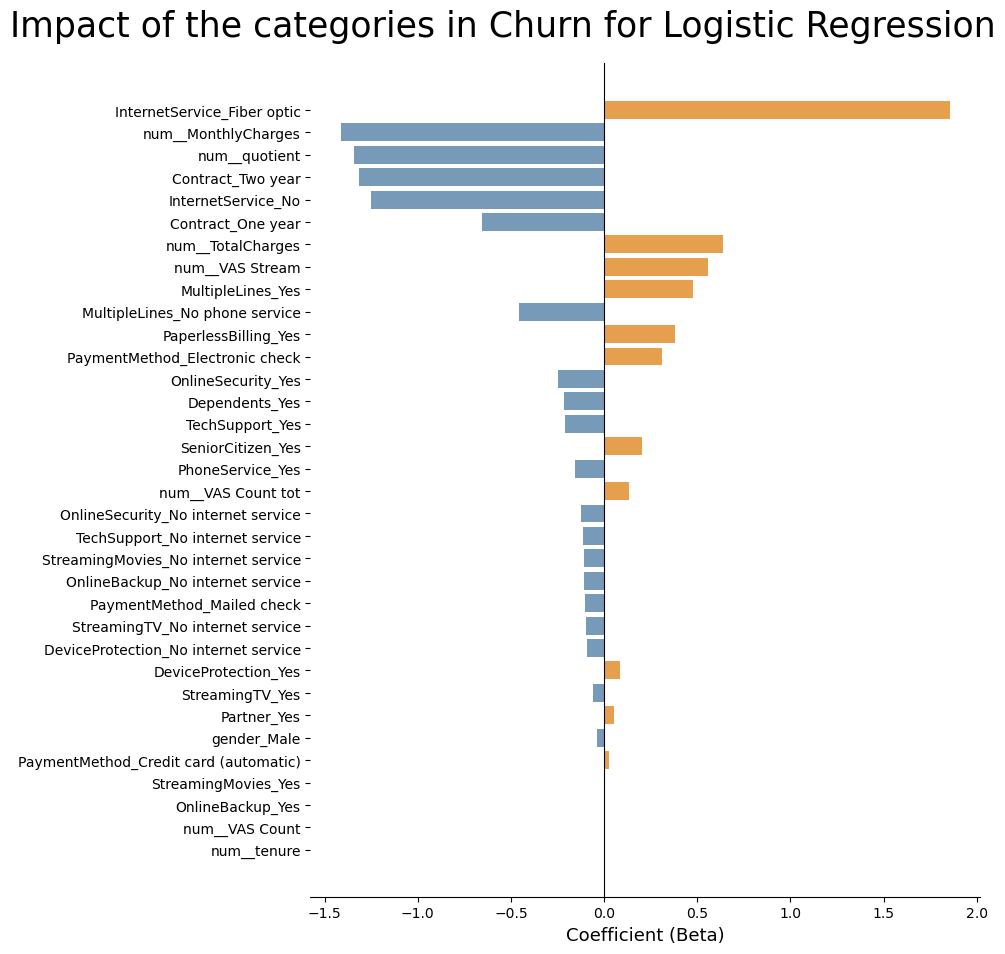

In [36]:
# extract the pipe used by randomsearch
best_pipe = search.best_estimator_

# use the preprocessor for the names and the model for coefficients
feature_names = best_pipe.named_steps['preprocess'].get_feature_names_out()
coefs = best_pipe.named_steps['model'].coef_[0]

# create a dataframe for plot
importances = pd.DataFrame({
    'Variable': feature_names,
    'Coefficients': coefs
})

# clean names
importances['Variable'] = importances['Variable'].str.replace('remainder__', '').str.replace('cat__', '').str.replace('onehot__', '')

#  order
importances['Abs_Coef'] = importances['Coefficients'].abs()
importances = importances.sort_values(by='Abs_Coef', ascending=True)

fig = plt.figure(figsize=(10, 10)) 
colors = ['#E08920' if c > 0 else '#5481A6' for c in importances['Coefficients']]


plt.barh(importances['Variable'], importances['Coefficients'], color=colors, alpha=0.8)
plt.axvline(0, color='black', linewidth=0.8)
sns.despine(top=True, right=True, left=True)
fig.suptitle('Impact of the categories in Churn for Logistic Regression',  y=0.95)
plt.xlabel('Coefficient (Beta)')
plt.tight_layout()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

The coefficients indicate that:
- Being a fiber optic client is the most relevant condition associated with churn.
- Duration of contract is a relevant feature; contracts for one and two years are in the top 5 against prone.
- A high monthly charge is related to a lower likelihood of churn.
- A high total charge is related to a higher likelihood of churn.
- Telephone-only customers have a low propensity to churn.
- The number of streaming VAS increases the propensity to churn

### Machine Learning Summary

**Models Evaluated:** Logistic Regression, Support Vector Classifier (SVC), Random Forest, and XGBoost.<br>
**Preprocessing:** StandardScaler for numerical variables and OneHotEncoder for categorical variables.<br>
**Data Split:** Stratified Train-Test split (80% - 20%).

**Model Selection:** Conducted using **Cross-Validation with Pipelines** to prevent data leakage.<br>
**Final Model: Logistic Regression** was selected based on the AUC metric.<br>
**Hyperparameter Tuning:** Performed via RandomizedSearchCV.<br>
AUC (Train): 0.8417<br>
**AUC (Test): 0.8517**

**Decile Grouping & Lift Analysis:** <br>
**Lift: 2.8x** in the highest decile.<br>
Concentration: 66% of total churners are captured within the top three deciles.

**Error Rate:** Very low False Negative rate (4.7%), meaning the model successfully identified all but 66 churners in the test set.

**Feature Importance & Insights:** <br>
Based on the model coefficients, we observed the following:<br>
- Fiber Optic: Having fiber optic service is the strongest predictor for churn.
- Contract Duration: Long-term contracts (one and two years) are among the top 5 features that prevent churn.
- Monthly Charges: Higher monthly charges are surprisingly correlated with a lower likelihood of churn (once other variables are controlled).
- Total Charges: Higher total charges are associated with an increased likelihood of churn.
- Service Type: "Telephone-only" customers show a low propensity to churn.
- Streaming Services: A higher number of streaming-related VAS (Value Added Services) increases the likelihood of churn.

## Business Analysis

We consider the "customer lifetime value"
$$
CLV= MI_{av} \times M \times CLT 
$$
where $MI_{av}$ is the average of monthly incomes, $M$ is the profit margin (for our calculations we consider 50%) and $CLT$ is the client lifetime. Due to the lack of survival modeling, we approximate $CLT$ using observed tenure mean.

In [37]:
M = 0.5 # margin
CLV = np.mean(df['MonthlyCharges'])*M*np.mean(df['tenure'])
print("CLV is {:.2f} ".format(CLV) ) 

CLV is 1050.44 


The cost of "doing nothing" for a client is the product between the CLV and the churn rate:

In [38]:
C_rate = df['Churn'].value_counts(normalize=True)[1]
print('Cost of "doing nothing" for client {:.2f} '.format(CLV*C_rate)) 

Cost of "doing nothing" for client 279.19 


The Revenue at Risk represents the Expected Loss of 'doing nothing', calculated as the product of the CLV, the predicted churn rate, and the total number of clients.

In [39]:
print('Revenue at risk {:.2f} '.format(CLV*C_rate*(df.shape)[0]) )

Revenue at risk 1963266.42 


Given this substantial amount, we evaluate two potential retention strategies for retaining clients with the highest probability of churn according to our prediction. It's worth mentioning that the targets are for groups of clients, not individuals, and we assume a homogeneity in the client response to the campaign.

In next subsection we consider differnts target groups for retention campaigns. In all cases a cost of 20 USD per client, and three possible scenarios:

- Pessimistic: success of 5% 
- Neutral: success of 10%
- Optimistic: success of 20%

In [40]:
cost_client = 20

scenarios ={
            'Pessimistic' : 0.05,
            'Neutral' : 0.1,
            'Optimistic': 0.2
            }

For each target group and scenario, we calculate:
The retained customers:
$$
Ret_{cust} = \#Clients C_{rate} \times S_{rate}
$$
where $\#clients$ is the number clients in the decile, $C_{rate}$ is the churn rate and $S_{rate}$ is the success rate of the campaign.

The gross benefit:
$$
G_{b} = Ret_{cust} \times CLV
$$

The campaign cost
$$
Camp_{cost} = \#clients \times U_cost
$$
where $\#clients$ is the number of target clients for the campaign and $U_{cost}$ is the cost per client.

Finally, the ROI
$$
ROI=\frac{G_b-Camp_{cost}}{Camp_{cost}}
$$

In [41]:
def calculate_campaign_roi(customers, churn_rate, clv, cost_per_customer, scenarios):
    """Calculate ROI for retention campaign scenarios
    customers: amount of customers reached
    churn_rate: churn rate of the set of customers reached
    clv: clv of customers reached
    cost_per_customer: cost per customer of the campaign
    scenarios: dictionary of scenarios (key) and probabilities"""
    
    total_cost = customers * cost_per_customer

    results={}
    for name, eff in scenarios.items():
        retained = customers * churn_rate * eff
        benefit = retained * clv
        net_benefit = benefit - total_cost
        roi = net_benefit / total_cost
    
        results[name] = {
            'retained': retained,
            'benefit': benefit,
            'net_benefit': net_benefit,
            'roi': roi
            }
        
        print(f"\n{name} ({eff*100:.0f}%):")
        print(f"  Retained customers: {retained:.0f}")
        print(f"  Benefit: {benefit:,.0f} USD")
        print(f"  Cost: {total_cost:,.0f} USD")
        print(f"  Net Benefit: {net_benefit:,.0f} USD")
        print(f"  ROI: {roi:.2f}")

### Retention campaign focused on churners 

Our model selects a client as a potential churner when the probability of churn is 50% or higher. In this campaign, we focuses in all such clients.


In this subset, the $CLV$ and the revenue at risk is

In [42]:
churn_mask = df_results['prob']>0.5 # select clients tagged as churn
customers_ch = churn_mask.sum()  # count
churn_rate_ch = df.loc[df_results[churn_mask].index, 'Churn'].mean() # churn rate in the set of tagged as churn
churners = df.loc[df_results[churn_mask].index, 'Churn'].sum() # churn clients in the set of tagged as churn

CLV_ch = (df.loc[df_results[churn_mask].index, 'MonthlyCharges'].mean()
              *df.loc[df_results[churn_mask].index, 'tenure'].mean()
              *M)


revenue_at_risk = churners * CLV_ch
print(f"CLV: {CLV_ch:,.0f} USD")
print(f"Revenue at risk: {revenue_at_risk:,.0f} USD")



CLV: 616 USD
Revenue at risk: 189,786 USD


Then, we calculate of the campaing under each scenario:

In [43]:
calculate_campaign_roi(customers_ch,churn_rate_ch, CLV_ch, cost_client, scenarios)


Pessimistic (5%):
  Retained customers: 15
  Benefit: 9,489 USD
  Cost: 12,320 USD
  Net Benefit: -2,831 USD
  ROI: -0.23

Neutral (10%):
  Retained customers: 31
  Benefit: 18,979 USD
  Cost: 12,320 USD
  Net Benefit: 6,659 USD
  ROI: 0.54

Optimistic (20%):
  Retained customers: 62
  Benefit: 37,957 USD
  Cost: 12,320 USD
  Net Benefit: 25,637 USD
  ROI: 2.08


If we project this results fron test set to the whole clients set:

In [44]:
total_customers_ch = int(df.shape[0] * (customers_ch/df_results.shape[0]))  # we project the same proportion over the whole df

revenue_at_risk = churners * CLV_ch
print(f"Revenue at risk: {revenue_at_risk:,.0f} USD")
calculate_campaign_roi(total_customers_ch , churn_rate_ch , CLV_ch, cost_client, scenarios)

Revenue at risk: 189,786 USD

Pessimistic (5%):
  Retained customers: 77
  Benefit: 47,416 USD
  Cost: 61,560 USD
  Net Benefit: -14,144 USD
  ROI: -0.23

Neutral (10%):
  Retained customers: 154
  Benefit: 94,831 USD
  Cost: 61,560 USD
  Net Benefit: 33,271 USD
  ROI: 0.54

Optimistic (20%):
  Retained customers: 308
  Benefit: 189,663 USD
  Cost: 61,560 USD
  Net Benefit: 128,103 USD
  ROI: 2.08


From the scenarios under consideration, only the pessimistic one produces a negative ROI. The neutral yields 0.54 USD in net profit for every dollar invested and the optimistic yields 2.08 UDS in net profit for every dollar invested (a total return of 3.08 USD).

Let's consider the breakeven analysis

In [45]:
breakeven = (churn_mask.shape[0] * cost_client) / (customers_ch  * CLV_ch)

print(f"Rention rate: {breakeven*100:.2f}%")

Rention rate: 7.41%


That's mean that we need to retain 431 of the churn clients in order to get a positive ROI.

### Retention campaign focused on decile 10

By selecting clients in this decile, we are almost three times more likely to identify churners.

In this group of 141 clients (a decile of the test set), the $CLV$ is $CLV_{10}$. The revenue at risk is obtained by $CLV_{10}\times C_{10}$, where $C_{10}$ is the number of churners in decile 10.

In [46]:
decile_mask =df_results['decil']==10
no_cli = sum(decile_mask)

churn_rate_d10 = df.loc[df_results[decile_mask].index, 'Churn'].mean() # churn rate in the decile 10
churners_d10 = df.loc[df_results[decile_mask].index, 'Churn'].sum() # churn clients in the decile 10

print(df_results.loc[df_results[decile_mask].index,'prob'].min())
CLV_10 = df.loc[df_results[decile_mask].index, 'MonthlyCharges'].mean()*df.loc[df_results[decile_mask].index, 'tenure'].mean()*M

print("CLV_10 is {:.2f} ".format(CLV_10) )

revenue_at_risk = churners_d10 * CLV_10
print(f"Revenue at risk in decile 10: {revenue_at_risk:,.0f} USD")

0.8453183331260073
CLV_10 is 256.60 
Revenue at risk in decile 10: 26,687 USD


Then, we calculate of the campaing under each scenario:

In [47]:
calculate_campaign_roi(no_cli, churn_rate_d10, CLV_10, 20, scenarios)


Pessimistic (5%):
  Retained customers: 5
  Benefit: 1,334 USD
  Cost: 2,820 USD
  Net Benefit: -1,486 USD
  ROI: -0.53

Neutral (10%):
  Retained customers: 10
  Benefit: 2,669 USD
  Cost: 2,820 USD
  Net Benefit: -151 USD
  ROI: -0.05

Optimistic (20%):
  Retained customers: 21
  Benefit: 5,337 USD
  Cost: 2,820 USD
  Net Benefit: 2,517 USD
  ROI: 0.89


If we project the results of these scenarios from the test set to the full client base:

In [48]:
total_customers_10 = int(df.shape[0] * 0.10)  # 0.1 because is a decile
C_cost = total_customers_10*cost_client
churners_full_10 = int(total_customers_10 * churn_rate_d10)

calculate_campaign_roi(total_customers_10 , churn_rate_d10 , CLV_10, cost_client, scenarios)


Pessimistic (5%):
  Retained customers: 26
  Benefit: 6,653 USD
  Cost: 14,060 USD
  Net Benefit: -7,407 USD
  ROI: -0.53

Neutral (10%):
  Retained customers: 52
  Benefit: 13,305 USD
  Cost: 14,060 USD
  Net Benefit: -755 USD
  ROI: -0.05

Optimistic (20%):
  Retained customers: 104
  Benefit: 26,611 USD
  Cost: 14,060 USD
  Net Benefit: 12,551 USD
  ROI: 0.89


From the scenarios under consideration, only the optimistic one produces a positive ROI, yielding 0.89 USD in net profit for every dollar invested (a total return of 1.89 USD).

Let's consider the breakeven analysis

In [49]:
breakeven = (total_customers_10 * cost_client) / (churners_full_10 * CLV_10)

print(f"Retention rate: {breakeven*100:.2f}%")

Retention rate: 10.58%


Therefore, a campaign with more than 10% success rate is needed in order to get a positive ROI.

### Retention campaign focused on deciles 8, 9 and 10 together

In this section, we analyze the effect of a campaign focused on the last three deciles. These deciles include 66% of churned clients while representing only 30% of the customer base.


The $CLV$ and revenue at risk for clients in deciles 8, 9 and 10:

In [50]:
# for deciles 8-10
deciles_target = [8, 9, 10]
decile_mask = df_results['decil'].isin(deciles_target)


customers_8_9_10 = decile_mask.sum()  # In test set
churn_rate_8_9_10 = df.loc[df_results[decile_mask].index, 'Churn'].mean()
churners_8_9_10 = df.loc[df_results[decile_mask].index, 'Churn'].sum()

CLV_8_9_10 = (df.loc[df_results[decile_mask].index, 'MonthlyCharges'].mean()
              *df.loc[df_results[decile_mask].index, 'tenure'].mean()
              *M)

float(round(CLV_8_9_10*churn_rate_d10*customers_8_9_10*3/10,2))

revenue_at_risk = churners_8_9_10 * CLV_8_9_10
print("CLV_8_9_10 is {:.2f} ".format(CLV_10) )
print(f"Revenue at risk in deciles 8-10: {revenue_at_risk:,.0f} USD")

CLV_8_9_10 is 256.60 
Revenue at risk in deciles 8-10: 126,652 USD


Then, we calculate the impact under each scenario:

In [51]:
calculate_campaign_roi(customers_8_9_10 , churn_rate_8_9_10  , CLV_8_9_10, cost_client, scenarios)


Pessimistic (5%):
  Retained customers: 12
  Benefit: 6,333 USD
  Cost: 8,440 USD
  Net Benefit: -2,107 USD
  ROI: -0.25

Neutral (10%):
  Retained customers: 25
  Benefit: 12,665 USD
  Cost: 8,440 USD
  Net Benefit: 4,225 USD
  ROI: 0.50

Optimistic (20%):
  Retained customers: 50
  Benefit: 25,330 USD
  Cost: 8,440 USD
  Net Benefit: 16,890 USD
  ROI: 2.00


Projecting this result over the complete set:

In [52]:
# Projection to the whole set
total_customers_8_9_10 = int(df.shape[0] * 0.30)  # 0.3 because are 3 deciles

calculate_campaign_roi(total_customers_8_9_10 , churn_rate_8_9_10  , CLV_8_9_10, cost_client, scenarios)


Pessimistic (5%):
  Retained customers: 62
  Benefit: 31,648 USD
  Cost: 42,180 USD
  Net Benefit: -10,532 USD
  ROI: -0.25

Neutral (10%):
  Retained customers: 124
  Benefit: 63,296 USD
  Cost: 42,180 USD
  Net Benefit: 21,116 USD
  ROI: 0.50

Optimistic (20%):
  Retained customers: 249
  Benefit: 126,592 USD
  Cost: 42,180 USD
  Net Benefit: 84,412 USD
  ROI: 2.00


From the scenarios under consideration, only the pessimistic scenario would produce a negative ROI. 

Under the neutral scenario, the net profit is 0.60 USD for each dollar invested, representing an ROI of 0.6. 

In the optimistic scenario, the ROI reaches 2.19. This indicates that for every 1.00 USD invested in the campaign, the company generates 2.19 USD in net profit.

Let us now consider the breakeven analysis.

In [53]:
breakeven = (customers_8_9_10 * cost_client) / (churn_rate_8_9_10*customers_8_9_10 * CLV_8_9_10)
print(f"Retention rate: {breakeven*100:.2f}%")

Retention rate: 6.66%


Therefore, a success rate above 7% in the retention campaign would generate a positive ROI.

### Cost-Benefit Optimization Strategy

Our predictive model identifies different levels of churn risk, and later we target clients grouped according to their risk. In this section, we target the clients in order to maximize the ROI.

The next plot shows the ROI for the three scenarios and different thresholds of churn probability.

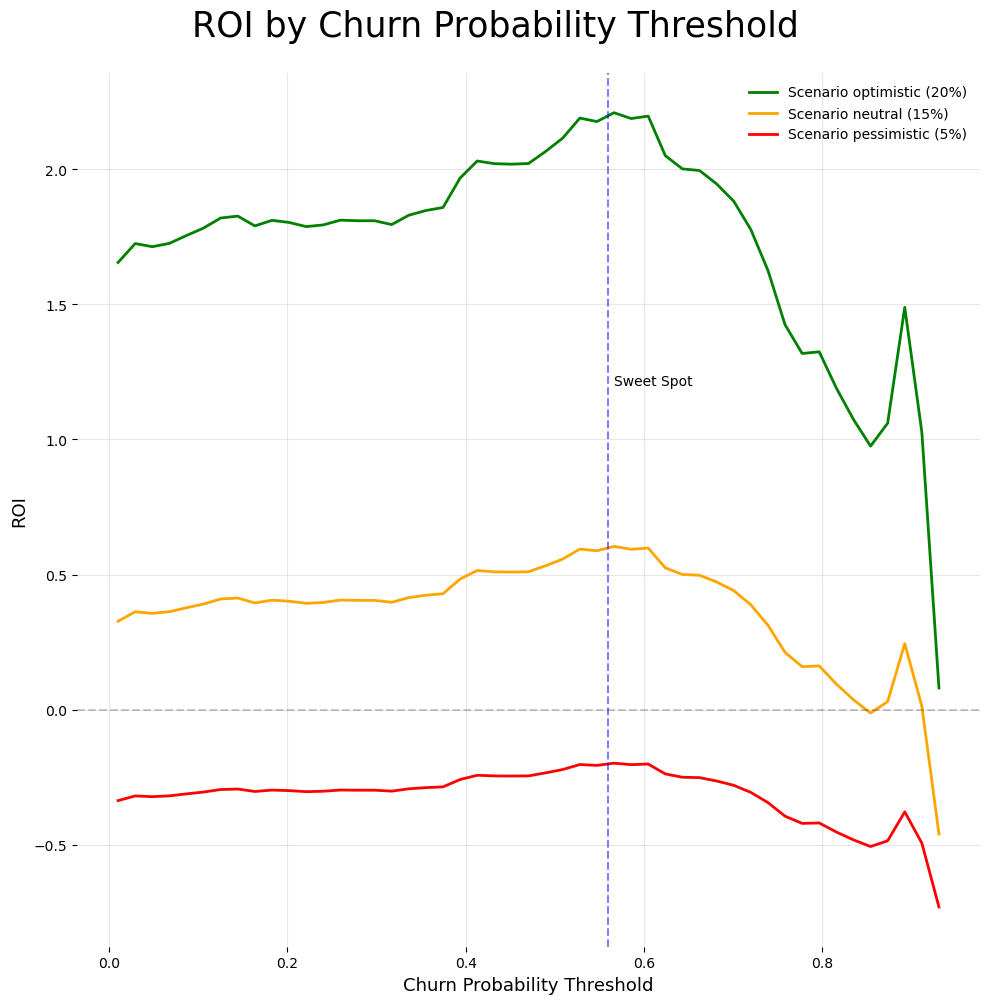

In [54]:
def simulate_roi_by_threshold(df, df_results, cost_per_customer, scenarios, M=0):
    """
    Plot ROI curves by threshold
    df: original dataframe
    df_results: dataframe with 'prob', churn probability for the test set.
    cost_per_customer: campaign cost per customer 
    scenarios: dict with scenarios and their probability of success for the campaign
    M: gross margin
    """    
    thresholds = np.linspace(0.01, 0.95, 50)
    
    # dict of roi curves
    roi_curves = {name: [] for name in scenarios.keys()}
    valid_thresholds = []

    for u in thresholds:
        churn_mask = df_results['prob'] > u
        indices = df_results[churn_mask].index
        
        # skip threshold without clients
        if len(indices) < 1:
            continue
            
        valid_thresholds.append(u)
        
        # extract data for threshold u
        customers = churn_mask.sum()
        actual_churn_rate = df.loc[indices, 'Churn'].mean()
        clv_avg = (df.loc[indices, 'MonthlyCharges'].mean() * df.loc[indices, 'tenure'].mean() * M)
        
        total_cost = customers * cost_per_customer

        # Calculate ROI for each scenario and threshold u
        for name, eff in scenarios.items():
            retained = customers * actual_churn_rate * eff
            net_benefit = (retained * clv_avg) - total_cost
            roi = net_benefit / total_cost if total_cost > 0 else 0
            roi_curves[name].append(roi)

    # plot
    fig = plt.figure(figsize=(10, 10))
    color_list = ['green', 'orange', 'red']
    for i, (name, rois) in enumerate(roi_curves.items()):
        plt.plot(valid_thresholds, rois, label=f'Scenario {name}', linewidth=2,color =color_list[i])

    
    fig.suptitle('ROI by Churn Probability Threshold',  y=1)
    plt.xlabel('Churn Probability Threshold')
    plt.ylabel('ROI')
    plt.legend(frameon=False)
    plt.axhline(0, color='black', linestyle='--',alpha=0.2)
    plt.grid(False)
    plt.grid(True, alpha=0.3)
    plt.axvline(x=0.56, color='blue', linestyle='--', alpha=0.5, label='Optimal threshold')
    plt.annotate('Sweet Spot', xy=(0.61, 1.2), ha='center')
    ax = plt.gca()
    ax.spines['bottom'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.show()
    return
# --- Ejecución ---
mis_escenarios = {
    'optimistic (20%)': 0.20,
    'neutral (15%)': 0.1,
    'pessimistic (5%)': 0.05
}

simulate_roi_by_threshold(df, df_results, cost_per_customer=20, scenarios=mis_escenarios, M=0.5)

Applying a 0.50-0.6 churn probability threshold to our campaign selection yields the optimal ROI. We consider 0.56 as the optimum.

**Note on threshold > 0.85:** The ROI increase at very high thresholds is likely a statistical artifact due to small sample sizes. At threshold 
0.9, we only contact ~50 customers, making the ROI estimate unstable. 

Focusing on clients with churn probability of 0.56 and above.

In [55]:
churn_mask = df_results['prob']>0.56 # select clients tagged as churn
customers_ch = churn_mask.sum()  # count
churn_rate_ch = df.loc[df_results[churn_mask].index, 'Churn'].mean() # churn rate in the set of tagged as churn
churners = df.loc[df_results[churn_mask].index, 'Churn'].sum() # churn clients in the set of tagged as churn

CLV_ch = (df.loc[df_results[churn_mask].index, 'MonthlyCharges'].mean()
              *df.loc[df_results[churn_mask].index, 'tenure'].mean()
              *M)

revenue_at_risk = churners * CLV_ch
print(f"CLV: {CLV_ch:,.0f} USD")
print(f"Revenue at risk: {revenue_at_risk:,.0f} USD")

CLV: 595 USD
Revenue at risk: 173,204 USD


Then, we calculate the impact under each scenario:

In [56]:
calculate_campaign_roi(customers_ch, churn_rate_ch, CLV_ch, cost_client, scenarios)


Pessimistic (5%):
  Retained customers: 15
  Benefit: 8,660 USD
  Cost: 10,720 USD
  Net Benefit: -2,060 USD
  ROI: -0.19

Neutral (10%):
  Retained customers: 29
  Benefit: 17,320 USD
  Cost: 10,720 USD
  Net Benefit: 6,600 USD
  ROI: 0.62

Optimistic (20%):
  Retained customers: 58
  Benefit: 34,641 USD
  Cost: 10,720 USD
  Net Benefit: 23,921 USD
  ROI: 2.23


Projecting this result over the complete set:

In [57]:
total_customers_ch = int(df.shape[0] * (customers_ch/df_results.shape[0]))  # we project the same proportion over the whole df

revenue_at_risk = churners * CLV_ch
print(f"Revenue at risk: {revenue_at_risk:,.0f} USD")
calculate_campaign_roi(total_customers_ch , churn_rate_ch , CLV_ch, cost_client, scenarios)

Revenue at risk: 173,204 USD

Pessimistic (5%):
  Retained customers: 73
  Benefit: 43,269 USD
  Cost: 53,560 USD
  Net Benefit: -10,291 USD
  ROI: -0.19

Neutral (10%):
  Retained customers: 145
  Benefit: 86,537 USD
  Cost: 53,560 USD
  Net Benefit: 32,977 USD
  ROI: 0.62

Optimistic (20%):
  Retained customers: 291
  Benefit: 173,075 USD
  Cost: 53,560 USD
  Net Benefit: 119,515 USD
  ROI: 2.23


From the scenarios under consideration, only the pessimistic scenario would produce a negative ROI. 

Under the neutral scenario, the net profit is 0.62 USD for each dollar invested, representing an ROI of 0.62. 

In the optimistic scenario, the ROI reaches 2.23. This indicates that for every 1.00 USD invested in the campaign, the return is 3.23 USD.

Let us now consider the breakeven analysis.

In [58]:
breakeven = (churn_mask.shape[0] * cost_client) / (customers_ch  * CLV_ch)

print(f"Retention rate: {breakeven*100:.2f}%")

Retention rate: 8.82%


That's mean that we need to retain 236 of the 2679 potential churn clients in order to get a positive ROI.

### Business Analysis Summary

In [59]:
columns = pd.MultiIndex.from_product(
    [["Campaign d10", "Campaign d8-d10", "Campaign Churners", "Optimized campaign"],
     ["Pessimistic", "Neutral", "Optimistic"]]
)


index = [
    "Retained customers",
    "Benefit",
    "Cost",
    "Net Benefit",
    "ROI"
]
data = [
    [26, 52, 104, 62, 124, 249,77,154,308,73,145,291],
    [6653, 13305, 26611, 31648, 63296, 126592, 447416, 94381, 186663, 43269, 86537, 173075],
    [1406, 14060, 14060, 42180, 42180, 42180, 61560, 61560, 61560,53560,53560,53560],
    [-7407, -755, 12551, -10532, 21116, 84412, -14144, 33271, 128103, -10291, 32977, 119515],
    [-0.53, -0.05, 0.89, -0.25, 0.5, 2, -0.23, 0.54, 2.08, -0.19, 0.62, 2.23],
]

table = pd.DataFrame(data, index=index, columns=columns)


def highlight_roi(val):
    if val > 0:
        return "background-color: #d4edda; color: #155724; font-weight: bold;"
    elif val < 0:
        return "background-color: #f8d7da; color: #721c24; font-weight: bold;"
    return ""

styled = (
    table.style
    .map(highlight_roi, subset=pd.IndexSlice[["ROI"], :])
)

styled


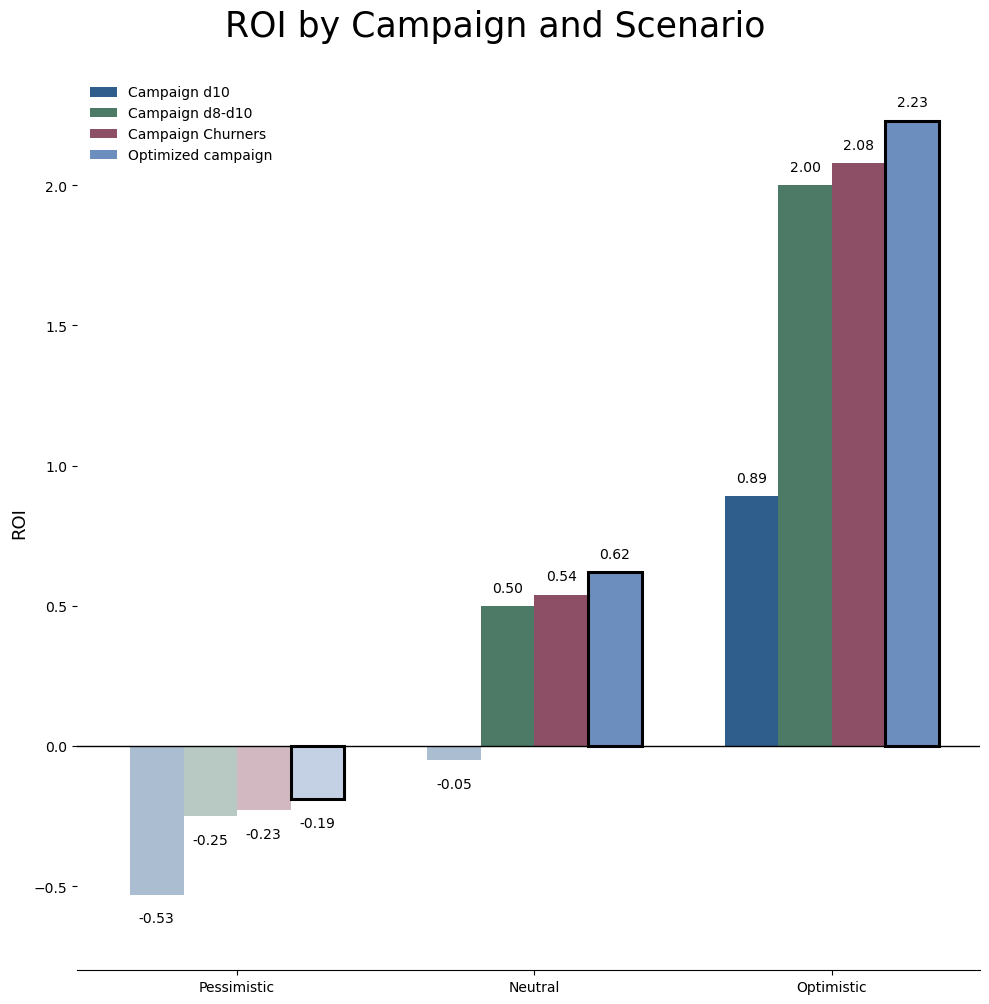

In [60]:


roi = table.loc["ROI"]

scenarios = ["Pessimistic", "Neutral", "Optimistic"]
campaigns = ["Campaign d10", "Campaign d8-d10", "Campaign Churners", "Optimized campaign"]


base_colors = {
    "Campaign d10": "#2F5D8C",   
    "Campaign d8-d10": "#4C7A67", 
    "Campaign Churners": "#8C4F66", 
    "Optimized campaign": "#6C8EBF" 
}

x = np.arange(len(scenarios))
width = 0.18

fig, ax = plt.subplots(figsize=(10,10))

for i, campaign in enumerate(campaigns):

    values = [roi[(campaign, scenario)] for scenario in scenarios]
    base_color = base_colors[campaign]

    for j, value in enumerate(values):

        # Negativos → mismo color pero suavizado
        if value < 0:
            color = mcolors.to_rgba(base_color, alpha=0.4)
        else:
            color = base_color

        scenario_values = [roi[(c, scenarios[j])] for c in campaigns]
        max_value = max(scenario_values)
        is_best = value == max_value

        ax.bar(
            x[j] + (i - 1.5) * width,
            value,
            width,
            color=color,
            edgecolor="black" if is_best else None,
            linewidth=2.2 if is_best else 0.7
        )

        ax.text(
            x[j] + (i - 1.5) * width,
            value + (0.04 if value >= 0 else -0.06),
            f"{value:.2f}",
            ha='center',
            va='bottom' if value >= 0 else 'top',
            #fontsize=9
        )

ax.axhline(0, color="black", linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(scenarios)
ax.set_ylabel("ROI")
#ax.set_title("ROI by Campaign and Scenario")
ax.set_ylim(-0.8, 2.4)
# Limpiar bordes superiores
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

fig.suptitle('ROI by Campaign and Scenario',  y=1)
# Leyenda limpia
for campaign in campaigns:
    ax.bar(0, 0, color=base_colors[campaign], label=campaign)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()


**Retention rate needed for d10 campaign: 10.58%**
**Retention rate needed for d8-d10 campaign: 6.66%**
**Retention rate needed for "churners" campaign: 7.41%**
**Retention rate needed for optimized campaign: 8.82%**

From the results: none of the considered campaigns have a positive ROI in the pessimistic scenario.

We observe that the optimized campaign has the highest ROI in all scenarios, but it has a higher breakeven threshold.

We can see that the campaign focused on clients predicted to churn—the simplest choice—is the second in terms of ROI. This campaign has a lower breakeven point and cost than the optimized campaign.

The campaign for d8-d10 is even less expensive and with a lower breakeven, but the expected ROI is also lower.

Finally, the d10 campaign is the cheapest, but with the highest breakeven requirement and lowest ROI under all scenarios.